# Laboratorio 1 - Preparación de un corpus y EDA

Notebook paso a paso, con celdas de explicación y comentarios en el código.

**Corpus:** Spanish News Classification  

## 1. Objetivo

Explorar el corpus, aplicar el pipeline de normalización visto en clase y responder las preguntas de EDA y análisis.

En esta parte se cargan las librerías que usaremos en todo el notebook:

- `pandas` para manipular la tabla del corpus.
- `re` para tokenización con expresiones regulares.
- `nltk` para el stemmer de español como respaldo.
- `matplotlib` para gráficas.
- `wordcloud` para la nube de palabras.
- `spaCy` para intentar la lematización real en español.

In [2]:
# Importaciones
from collections import Counter
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
import nltk
from nltk.corpus import stopwords as nltk_stopwords
from wordcloud import WordCloud

# Descargar recursos de NLTK (solo la primera vez)
nltk.download("stopwords")

# Cargar modelo de español
nlp = spacy.load("es_core_news_sm")

# Stopwords en español
ES_STOPWORDS = set(nltk_stopwords.words("spanish"))

# Rutas del proyecto
INPUT = Path("df_total.csv")          # Archivo de entrada


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/michelle/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
# Cargar el corpus
df = pd.read_csv(INPUT)
df.head()

,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra


## 2. Explorar el corpus antes de tocarlo

Aquí respondemos exactamente lo que pide el laboratorio:

- cuántos documentos tiene el corpus,
- qué columnas contiene,
- qué información guarda cada una,
- cuántas categorías hay y cómo se distribuyen,
- si hay filas vacías o duplicadas.

Esta exploración se hace **antes** de aplicar cualquier limpieza.

In [23]:
# Resumen básico del corpus
print("Documentos:", len(df))
print("Columnas:", df.columns.tolist())
print("\nVacíos por columna:\n", df.isna().sum())
print("\nFilas duplicadas:", int(df.duplicated().sum()))
print("\nDistribución de categorías:\n", df["Type"].value_counts())

Documentos: 1217
Columnas: ['url', 'news', 'Type']

Vacíos por columna:
 url     0
news    0
Type    0
dtype: int64

Filas duplicadas: 75

Distribución de categorías:
 Type
Macroeconomia     340
Alianzas          247
Innovacion        195
Regulaciones      142
Sostenibilidad    137
Otra              130
Reputacion         26
Name: count, dtype: int64


### Respuestas de exploración

- El corpus tiene **1217 documentos**.
- Las columnas son **url**, **news** y **Type**.
- `url` identifica la fuente o enlace de la noticia.  
- `news` contiene el texto completo de la noticia.  
- `Type` guarda la categoría temática.
- Se detectaron **0 filas vacías** y **75 filas duplicadas**.
- La distribución de categorías aparece en la tabla siguiente.

In [24]:
# Distribución de categorías
category_counts = df["Type"].value_counts()
category_counts

Type
Macroeconomia     340
Alianzas          247
Innovacion        195
Regulaciones      142
Sostenibilidad    137
Otra              130
Reputacion         26
Name: count, dtype: int64

# 3. Preparación del corpus

Ahora aplicamos el pipeline de normalización en el mismo orden del laboratorio:

1. Tokenización  
2. Minúsculas  
3. Eliminar puntuación  
4. Eliminar stopwords  
5. Lematización

Además, después de cada paso contaremos:
- **tokens**: ocurrencias totales,
- **tipos**: palabras distintas.

In [25]:
# Configuración del preprocesamiento
punct_re = re.compile(r"\w+|[^\w\s]", flags=re.UNICODE)
word_re = re.compile(r"^\w+$", flags=re.UNICODE)
stopwords = set(ES_STOPWORDS) | {"rt", "http", "https", "www", "com"}

# Tokenizar: divide cada texto en palabras y signos
def tokenize(text):
    return punct_re.findall(str(text))

# Pasar a minúsculas
def to_lower(tokens):
    return [t.lower() for t in tokens]

# Quitar puntuación
def remove_punct(tokens):
    return [t for t in tokens if word_re.match(t)]

# Quitar stopwords
def remove_stop(tokens):
    return [t for t in tokens if t not in stopwords]

# Lematizar con spaCy
def lemmatize_tokens(tokens):
    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc if token.lemma_ != "-PRON-"]

# Normalización final
def normalize_tokens(text):
    tokens = tokenize(text)
    tokens = to_lower(tokens)
    tokens = remove_punct(tokens)
    tokens = remove_stop(tokens)
    tokens = lemmatize_tokens(tokens)
    return tokens

In [26]:
# Medir tokens y tipos después de cada paso
def flatten(series):
    return [t for doc in series for t in doc]

stage_tokens = {
    "Tokenización": flatten(df["news"].apply(tokenize)),
    "Minúsculas": flatten(df["news"].apply(lambda x: to_lower(tokenize(x)))),
    "Eliminar puntuación": flatten(df["news"].apply(lambda x: remove_punct(to_lower(tokenize(x))))),
    "Eliminar stopwords": flatten(df["news"].apply(lambda x: remove_stop(remove_punct(to_lower(tokenize(x)))))),
    "Lematización": flatten(df["news"].apply(normalize_tokens)),
}

stage_summary = pd.DataFrame([
    {"Paso": stage, "Tokens": len(tokens), "Tipos": len(set(tokens))}
    for stage, tokens in stage_tokens.items()
])

stage_summary["Reducción de vocabulario vs. tokenización (%)"] = (
    (stage_summary.loc[0, "Tipos"] - stage_summary["Tipos"]) / stage_summary.loc[0, "Tipos"] * 100
).round(2)

stage_summary

,Paso,Tokens,Tipos,Reducción de vocabulario vs. tokenización (%)
0,Tokenización,684297,32606,0.00
1,Minúsculas,684297,29571,9.31
2,Eliminar puntuación,637564,29530,9.43
3,Eliminar stopwords,339170,29315,10.09
4,Lematización,339206,22398,31.31


## 4. ¿Qué es un EDA?

**EDA** significa *Exploratory Data Analysis* o **Análisis Exploratorio de Datos**.

Su objetivo es:
- entender la estructura del conjunto de datos,
- detectar errores, vacíos, duplicados y valores raros,
- identificar patrones, tendencias y distribuciones,
- decidir cómo limpiar, transformar o modelar los datos después.

En este laboratorio, el EDA nos ayuda a entender cómo se comporta el corpus antes de entrenar un modelo o hacer un análisis más profundo.

In [27]:
# Aplicar la normalización completa al corpus
df["tokens"] = df["news"].apply(normalize_tokens)
df["token_count"] = df["tokens"].str.len()
df.head()

,url,news,Type,tokens,token_count
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra,"[foro, banca, articulador, empresarial, desarr...",110
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones,"[regulador, valor, chino, decir, domingo, busc...",186
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas,"[industria, históricamente, masculino, aviació...",201
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia,"[dato, marzo, ipc, interanual, encadenar, deci...",259
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra,"[ayer, cartagena, dar, inicio, versión, número...",420


In [39]:
# Estadísticas globales
all_norm_tokens = flatten(df["tokens"])
freq = Counter(all_norm_tokens)
global_tokens = len(all_norm_tokens)
global_types = len(set(all_norm_tokens))
global_ttr = global_types / global_tokens
reduction_total = (len(set(stage_tokens["Tokenización"])) - global_types) / len(set(stage_tokens["Tokenización"])) * 100

pd.DataFrame([
    ["Tokens totales normalizados", global_tokens],
    ["Tipos totales normalizados", global_types],
    ["Riqueza léxica global (type/token)", round(global_ttr, 4)],
    ["Reducción total del vocabulario (%)", round(reduction_total, 2)],
], columns=["Métrica", "Valor"])

,Métrica,Valor
0,Tokens totales normalizados,339206.000
1,Tipos totales normalizados,22398.000
2,Riqueza léxica global (type/token),0.066
3,Reducción total del vocabulario (%),31.310


In [29]:
# Tabla de frecuencias: 20 palabras más frecuentes
top20 = pd.DataFrame(freq.most_common(20), columns=["Palabra", "Frecuencia"])
top20

,Palabra,Frecuencia
0,poder,2531
1,bbva,2527
2,año,2240
3,banco,1561
4,país,1524
5,empresa,1410
6,inflación,1404
7,nuevo,1292
8,hacer,1257
9,precio,1247


In [30]:
# Riqueza léxica por categoría
cat_rows = []
for cat, g in df.groupby("Type"):
    toks = flatten(g["tokens"])
    cat_rows.append({
        "Categoria": cat,
        "Tokens": len(toks),
        "Tipos": len(set(toks)),
        "type_token_ratio": len(set(toks)) / len(toks),
    })
category_richness = pd.DataFrame(cat_rows).sort_values("type_token_ratio", ascending=False)
category_richness

,Categoria,Tokens,Tipos,type_token_ratio
5,Reputacion,7815,2537,0.324632
4,Regulaciones,37783,7026,0.185957
0,Alianzas,49927,8666,0.173573
3,Otra,29092,4974,0.170975
6,Sostenibilidad,57540,8052,0.139937
1,Innovacion,61183,6871,0.112302
2,Macroeconomia,95866,9421,0.098273


**Riqueza léxica por categoría.**  
La categoría `Reputacion` presenta la mayor riqueza léxica relativa (**0.3246**) porque tiene pocos documentos y un vocabulario más variado en proporción. En cambio, `Macroeconomia` muestra la menor riqueza léxica relativa (**0.0983**), lo cual es coherente con una categoría grande y temática más repetitiva. Esto sugiere que las categorías más amplias tienden a repetir más vocabulario especializado.

## VISUALIZACION 

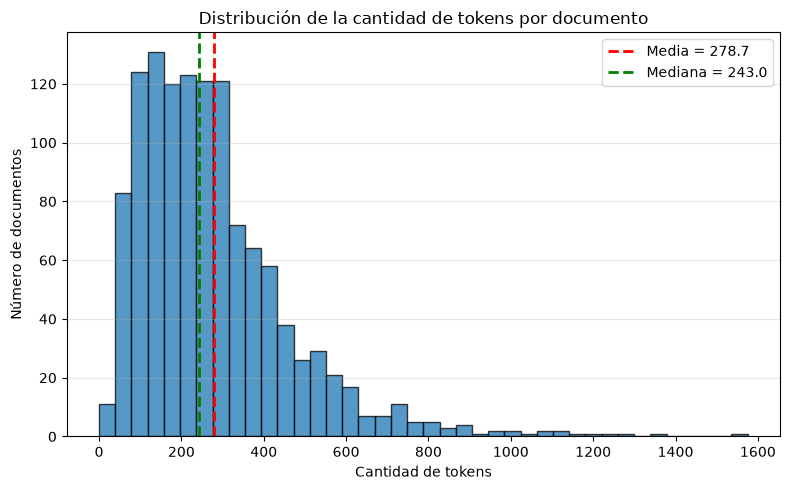

In [45]:
# Histograma de la cantidad de tokens por documento

media = df["token_count"].mean()
mediana = df["token_count"].median()

plt.figure(figsize=(8,5))

plt.hist(
    df["token_count"],
    bins="auto",
    edgecolor="black",
    alpha=0.75
)

plt.axvline(media,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Media = {media:.1f}")

plt.axvline(mediana,
            color="green",
            linestyle="--",
            linewidth=2,
            label=f"Mediana = {mediana:.1f}")

plt.title("Distribución de la cantidad de tokens por documento")
plt.xlabel("Cantidad de tokens")
plt.ylabel("Número de documentos")
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


/var/folders/c2/7hv2k_zd35380q4h8tgsvc3h0000gn/T/ipykernel_72939/1749766272.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["token_count"], vert=False)


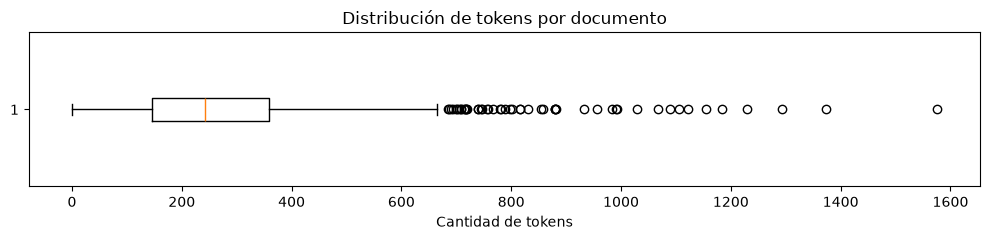

In [44]:
plt.figure(figsize=(10,2.5))

plt.boxplot(df["token_count"], vert=False)

plt.title("Distribución de tokens por documento")
plt.xlabel("Cantidad de tokens")

plt.tight_layout()
plt.show()

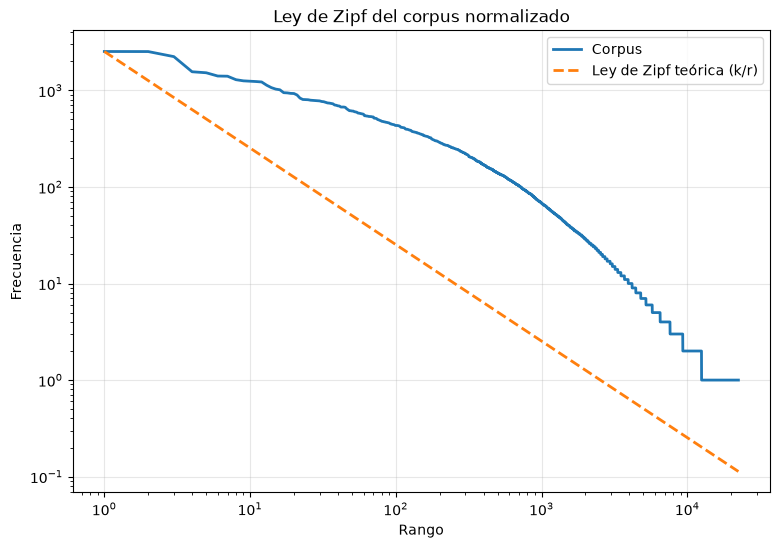

Pendiente aproximada: -1.374


In [42]:

# Ley de Zipf

freq_sorted = np.array(sorted(freq.values(), reverse=True))
ranks = np.arange(1, len(freq_sorted) + 1)

# Pendiente aproximada
zipf_slope, zipf_intercept = np.polyfit(np.log10(ranks), np.log10(freq_sorted), 1)

# Curva teórica
zipf_theoretical = freq_sorted[0] / ranks

plt.figure(figsize=(9,6))

plt.plot(ranks, freq_sorted,
         label="Corpus",
         linewidth=2)

plt.plot(ranks, zipf_theoretical,
         "--",
         label="Ley de Zipf teórica (k/r)",
         linewidth=2)

plt.xscale("log")
plt.yscale("log")

plt.title("Ley de Zipf del corpus normalizado")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

print(f"Pendiente aproximada: {zipf_slope:.3f}")


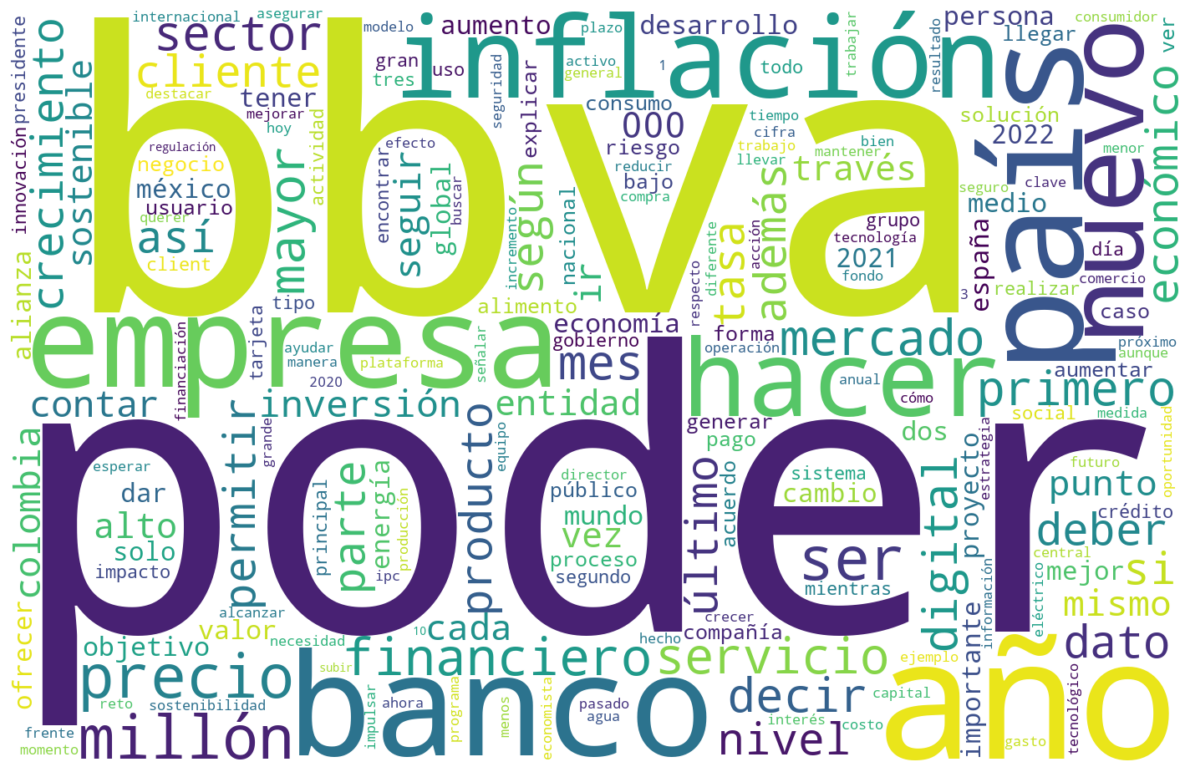

In [34]:


# Nube de palabras

wc = WordCloud(width=1400, height=900, background_color="white").generate_from_frequencies(freq)

plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()


In [38]:

# Comparación por categoría
# Se comparan las 10 palabras más frecuentes de dos categorías


def top_words_by_category(category, n=10):
    """
    Devuelve las n palabras más frecuentes de una categoría.
    
    Parámetros:
        category (str): Nombre de la categoría.
        n (int): Número de palabras a mostrar.
    
    Retorna:
        DataFrame con las palabras y su frecuencia.
    """
    
    # Obtener todos los tokens de la categoría seleccionada
    tokens_categoria = flatten(df.loc[df["Type"] == category, "tokens"])

    # Contar la frecuencia de cada palabra
    frecuencia = Counter(tokens_categoria)

    # Crear el DataFrame con las n palabras más frecuentes
    return pd.DataFrame(
        frecuencia.most_common(n),
        columns=["Palabra", "Frecuencia"]
    )


# Categorías a comparar
categorias = ["Innovacion", "Macroeconomia","Sostenibilidad","Alianzas"]

# Mostrar el Top 10 de cada categoría
for categoria in categorias:
    print(f"\nTop 10 palabras más frecuentes - {categoria}")
    display(top_words_by_category(categoria))


Top 10 palabras más frecuentes - Innovacion


,Palabra,Frecuencia
0,bbva,1120
1,poder,588
2,banco,415
3,cliente,398
4,digital,387
5,nuevo,370
6,empresa,362
7,dato,352
8,permitir,314
9,financiero,309



Top 10 palabras más frecuentes - Macroeconomia


,Palabra,Frecuencia
0,inflación,1331
1,precio,1016
2,año,1003
3,poder,679
4,bbva,547
5,mes,530
6,mayor,523
7,tasa,516
8,país,456
9,aumento,421



Top 10 palabras más frecuentes - Sostenibilidad


,Palabra,Frecuencia
0,bbva,481
1,poder,436
2,sostenible,387
3,energía,374
4,agua,274
5,año,249
6,sostenibilidad,231
7,eléctrico,231
8,objetivo,223
9,empresa,205



Top 10 palabras más frecuentes - Alianzas


,Palabra,Frecuencia
0,alianza,427
1,país,369
2,poder,341
3,colombia,292
4,millón,274
5,año,261
6,nuevo,256
7,empresa,237
8,hacer,203
9,mercado,193


**Comparación por categoría.**  
La comparación de categorías muestra que el vocabulario cambia según el tema. En `Innovacion` aparecen palabras como `cliente`, `digital`, `financiero` y `plataforma`, mientras que en `Macroeconomia` predominan `inflación`, `precio`, `tasa`, `año` y `país`. Esto confirma que el corpus está bien organizado por temática y que el preprocesamiento conserva diferencias útiles para el análisis.

### Lectura rápida de los resultados

- La distribución de tokens por documento suele ser asimétrica: algunos documentos son mucho más largos que otros.  
- La curva de Zipf en escala log-log debería verse aproximadamente lineal y descendente.  
- En las categorías, el vocabulario cambia según el tema: por ejemplo, en `Innovacion` suelen dominar términos tecnológicos y de cliente, mientras que en `Macroeconomia` aparecen palabras de inflación, precios, tasas y crecimiento.

### 6. Análisis de resultados

**Ley de Zipf.**  
La curva obtenida en escala log-log muestra un comportamiento cercano al teórico. La pendiente aproximada fue de **-1.374**, por lo que la distribución conserva la forma descendente esperada en un corpus natural. 

La diferencia con la curva ideal se explica porque el corpus no es completamente homogéneo: está compuesto por noticias de negocios y economía, con muchas repeticiones de nombres propios, instituciones y términos muy frecuentes como `bbva`, `banco`, `inflación` o `poder`.

### Reducción del vocabulario
La normalización sí tuvo un efecto claro. El vocabulario pasó de **32,606 tipos** en la tokenización inicial a **22,398 tipos** después de la lematización, es decir, una reducción total de **31.31%** respecto al vocabulario inicial. Por pasos, la reducción del vocabulario fue aproximadamente:  
- **Minúsculas:** de 32,606 a 29,571 tipos (**9.31%**).  
- **Eliminar puntuación:** de 29,571 a 29,530 tipos (**0.14%**).  
- **Eliminar stopwords:** de 29,530 a 29,315 tipos (**0.73%**).  
- **Lematización:** de 29,315 a 22,398 tipos (**23.59%**).  

El paso con mayor impacto fue la **lematización**, porque unifica distintas formas flexionadas de una misma palabra en un solo lema.

### Efecto de eliminar stopwords
Quitar stopwords redujo bastante la cantidad total de tokens y ayudó a concentrar el análisis en palabras con más contenido semántico. 

En este corpus, esa limpieza no destruye el sentido general de las noticias porque la temática principal sigue estando marcada por sustantivos y nombres propios. 

Sin embargo, siempre hay que revisar el contexto ya que algunas palabras muy frecuentes pueden aportar mucha informacion 
